3. In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features. The observations are as follows.

 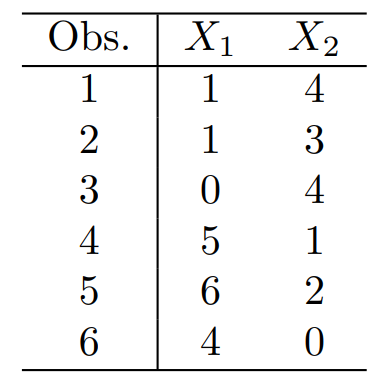

 (a) Plot the observations.

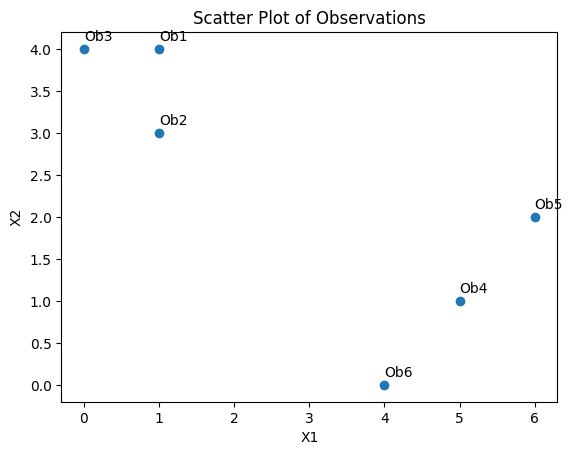

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
X1 = [1,1,0,5,6,4]
X2 = [4,3,4,1,2,0]
label = ["Ob1","Ob2","Ob3","Ob4","Ob5","Ob6"]

plt.scatter(X1,X2)
for i, (x, y) in enumerate(zip(X1, X2)):  # x, y 是點的座標
    plt.annotate(label[i], (x, y + 0.1))

plt.title("Scatter Plot of Observations")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

(b) Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [14]:
X = np.array([
    [1, 4],
    [1, 3],
    [0, 4],
    [5, 1],
    [6, 2],
    [4, 0]
])

# 隨機分配 cluster (1 或 2)
np.random.seed(42)  # 固定隨機種子，方便重現結果
labels = np.random.choice([1, 2], size=len(X))

# 轉成 DataFrame 方便檢視
df = pd.DataFrame(X, columns=["X1", "X2"])
df["Cluster"] = labels
df

,X1,X2,Cluster
0,1,4,1
1,1,3,2
2,0,4,1
3,5,1,1
4,6,2,1
5,4,0,2


(c) Compute the centroid for each cluster.

In [15]:
centroids = df.groupby("Cluster")[["X1", "X2"]].mean()
centroids

,X1,X2
Cluster,,
1,3.0,2.75
2,2.5,1.50


(d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [18]:
# 計算每個點到每個 centroid 的距離
centroids = np.array(centroids)
distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)

# 分配到最近的 centroid (index從0開始，所以加1)
new_labels = np.argmin(distances, axis=1) + 1

print("Distances:\n", distances)
print("\nNew cluster labels:", new_labels)

Distances:
 [[2.35849528 2.91547595]
 [2.01556444 2.12132034]
 [3.25       3.53553391]
 [2.65753645 2.54950976]
 [3.09232922 3.53553391]
 [2.92617498 2.12132034]]

New cluster labels: [1 1 1 2 1 2]


(e) Repeat (c) and (d) until the answers obtained stop changing.

In [48]:
#初始化 labels 和 df['Cluster']
np.random.seed(42) # 為了確保結果可重現
initial_labels = np.random.choice([1, 2], size=len(X)) 
newlabel = initial_labels.copy() # 將隨機label標籤設定給 newlabel
labels = newlabel.copy()
df['Cluster'] = labels.copy() 

while(True):
    centroids_df = df.groupby("Cluster")[["X1", "X2"]].mean()
    centroids = centroids_df.values # 使用 .values 轉為 NumPy Array
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    newlabels = np.argmin(distances, axis=1) + 1
    if np.array_equal(newlabels, labels):
        break
        
    # 將新的標籤賦值給 df 的 'Cluster' 欄位，確保下一次使用正確的 Centroids
    df['Cluster'] = newlabels.copy()
    # 更新 labels 變數，記錄本次的分組作為下次的舊狀態
    labels = newlabels.copy() 

print("Distances:\n", distances)
print("\nFinal cluster labels:", newlabels)
print(centroids)

Distances:
 [[0.47140452 5.        ]
 [0.74535599 4.47213595]
 [0.74535599 5.83095189]
 [5.08811251 0.        ]
 [5.58768487 1.41421356]
 [4.95535625 1.41421356]]

Final cluster labels: [1 1 1 2 2 2]
[[0.66666667 3.66666667]
 [5.         1.        ]]


(f) In your plot from (a), color the observations according to the cluster labels obtained.

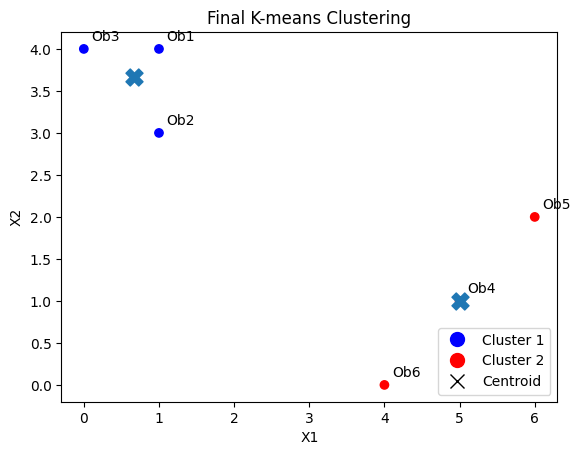

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The dataset coordinates
X1 = np.array([1, 1, 0, 5, 6, 4])
X2 = np.array([4, 3, 4, 1, 2, 0])
#Observations = np.arange(1, 7) # Observation numbers 1 to 6

final_labels = np.array([1, 1, 1, 2, 2, 2])
colors = ['blue' if label == 1 else 'red' for label in final_labels]

final_centroids = np.array([[2/3, 11/3],[5, 1]])

plt.scatter(X1, X2, c=colors)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], marker='X', s=150, label='Final Centroids') # Plot the final centroids
for i, (x, y) in enumerate(zip(X1, X2)):
    plt.annotate(label[i], (x + 0.1, y + 0.1))

# Create custom legends for clarity
import matplotlib.lines as mlines
blue_dot = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=10, label='Cluster 1')
red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Cluster 2')

plt.title('Final K-means Clustering')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(handles=[blue_dot, red_dot, mlines.Line2D([], [], color='black', marker='x', linestyle='None', markersize=10, label='Centroid')], loc='lower right')
plt.show()